In [1]:
import bacco
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils
import merger_tree_tools as mgt

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
def q_pos(mbID, npart=4320, BoxSize=500, mtng=False, idstart=0):
    
    if mtng:
        mbID[np.where(mbID>=1)] -= 20155392000
        mbID[np.where(mbID<1)] += 80621568000

    q = np.zeros(mbID.shape + (3,), dtype=np.float32)

    q[..., 0] = (mbID - idstart) // npart**2
    q[..., 1] = ( (mbID - idstart) // npart) % npart
    q[..., 2] = (mbID - idstart) % npart

    # normalize correctly
    q *= (BoxSize / npart)

    return q

### Load the Zoom

In [48]:
base = "/cosmos_storage/data_sharing/MN5_resims/1pmbin_2160_legacy/fiducial/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 100

zoom = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), numpart=4320**3)

_snap = 94
zoom_snap = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(_snap,_snap), dm_file="snapdir_{:03d}/snapshot_{:03d}".format(_snap,_snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(_snap,_snap), numpart=4320**3)


print(zoom.header['Redshift'])

2024-08-23 15:18:26,066 bacco.sims : Initialising simulation Default
2024-08-23 15:18:26,067 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/1pmbin_2160_legacy/fiducial/hydro_output/groups_100/fof_subhalo_tab_100
2024-08-23 15:18:26,073 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/1pmbin_2160_legacy/fiducial/hydro_output/groups_100/fof_subhalo_tab_100
2024-08-23 15:18:26,076 bacco.sims : ...done in 0.00944 s
2024-08-23 15:18:26,077 bacco.sims : Initialising simulation Default
2024-08-23 15:18:26,077 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/1pmbin_2160_legacy/fiducial/hydro_output/snapdir_094/snapshot_094
2024-08-23 15:18:26,177 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/1pmbin_2160_legacy/fiducial/hydro_output/snapdir_094/snapshot_094
2024-08-23 15:18:26,190 bacco.sims : ...done in 0.114 s


2.789151963173933


### Load the Original Sim

In [6]:
# we need this one for the indices (the saved selection is relative to this snapshot)
mtng_z0 = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=264)
mtng_z0.fof['halo_pos'][:,0] = (mtng_z0.fof['halo_pos'][:,0] - 125) % 500
mtng_z0.sub['pos'][:,0] = (mtng_z0.sub['pos'][:,0] - 125) % 500


mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=100)
mtng.fof['halo_pos'][:,0] = (mtng.fof['halo_pos'][:,0] - 125) % 500
mtng.sub['pos'][:,0] = (mtng.sub['pos'][:,0] - 125) % 500

print(mtng.header['Redshift'])

2024-08-23 11:54:36,347 bacco.sims : Initialising simulation Default
2024-08-23 11:54:36,349 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-23 11:54:36,373 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-23 11:54:36,378 bacco.sims : ...done in 0.0308 s
2024-08-23 11:54:36,385 bacco.sims : Reading 98233510 items for GroupPos


2024-08-23 11:54:43,424 bacco.sims : Reading 90246895 items for SubhaloPos
2024-08-23 11:54:48,639 bacco.sims : Initialising simulation Default
2024-08-23 11:54:48,640 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_100/fof_subhalo_tab_100
2024-08-23 11:54:48,642 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_100/fof_subhalo_tab_100
2024-08-23 11:54:48,664 bacco.sims : ...done in 0.025 s
2024-08-23 11:54:48,668 bacco.sims : Reading 116846005 items for GroupPos
2024-08-23 11:55:36,868 bacco.sims : Reading 124420311 items for SubhaloPos


2.789151963173933


### Cross-Match Selected Halos

In [7]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selections/2160-A/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

First cross-match z=0 to other z

In [ ]:
snap_0 = 264

tree = mgt.tree(snap_0=snap_0) # class object containing methods related to the merger-trees
tree.get_tree_props(final_sel)

In [ ]:
idx = tree.walk_tree()

sel_z = np.zeros(len(final_sel), dtype=int)

for i in range(len(final_sel)):
    sel_z[i] = tree.group_nr[i][idx[i,264-100]]

### Now cross-match those at same redshift

In [164]:
psel = np.where(zoom.fof['halo_m200b']>0)[0]

X1 = zoom.fof['halo_pos'][psel]
X2 = mtng.fof['halo_pos'][sel_z]

kdt = KDTree(X1, boxsize=500)
dist, ind = kdt.query(X2, k=100)

ind[np.where(dist==np.inf)] = -1

In [165]:
M1 = 1e10 * zoom.fof['halo_m200b'][psel][ind]
M2 = 1e10 * mtng.fof['halo_m200b'][sel_z]

pos1 = np.transpose(zoom.fof['halo_pos'][psel][ind], (2,0,1))
pos2 = mtng.fof['halo_pos'][sel_z].T

vmax_1 = zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel][ind]]
vmax_2 = mtng.sub['vmax'][mtng.fof['halo_firstsub'][sel_z]]


In [166]:
def metric(m1,m2,v1,v2,dist,a,b,c):

    #d_m = np.abs(np.log10(m1[...,np.newaxis]/m2))
    #d_v = np.abs(v1[...,np.newaxis]-v2)

    d_m = np.abs( (1 - m1[...,np.newaxis]/m2)/0.2 )
    d_v = np.abs( (1 - v1[...,np.newaxis]/v2)/0.2 )

    return dist*a + d_m*b + d_v*c


In [167]:
d = metric(M2,M1,vmax_2,vmax_1,dist,100,1,1)

xmatch = np.zeros(len(M1), dtype=int)
dmatch = np.zeros(len(M1))
metr = np.zeros(len(M1))

for i in range(len(M1)):
    metr[i] = d[i].min()
    xmatch[i] = ind[i,np.where(d[i]==d[i].min())[0][0]]
    dmatch[i] = dist[i,np.where(d[i]==d[i].min())[0][0]]

In [168]:
ihalo = 450

In [170]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(16,5))

w = np.where(dmatch>0.3)

Xarr = np.log10(1e10*mtng.fof['halo_m200b'][sel_z])
Yarr = (zoom.fof['halo_m200b'][psel[xmatch]] / mtng.fof['halo_m200b'][sel_z])

Xarr_out = np.log10(1e10*mtng.fof['halo_m200b'][sel_z][w])
Yarr_out = (zoom.fof['halo_m200b'][psel[xmatch]][w] / mtng.fof['halo_m200b'][sel_z][w])

ax[0].plot(Xarr, Yarr, marker='o', color='C0', ms=3, ls='')
ax[0].plot(Xarr_out, Yarr_out, marker='o', color='C3', ms=3, ls='')

ax[0].plot(Xarr[ihalo], Yarr[ihalo], marker='*', color='y', ms=5, ls='')

ax[0].axhline(1, color='k')

ax[0].set_xlabel('Full MTNG M200')
ax[0].set_ylabel('Fiducial Zoom M200 / Full MTNG M200')

#

ax[1].set_xlabel('Full MTNG M200')
ax[1].set_ylabel('Distance$[Mpc/h]$')

ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z]), dmatch, marker='o', color='C0', ms=3, ls='')
ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z][ihalo]), dmatch[ihalo], marker='*', color='y', ms=5, ls='')

ax[1].set_xlim(8,14)
ax[1].axhline(0.3, color='C3')

ax[1].set_yscale('log')

#

ax[2].set_xscale('log')

ax[2].set_xlabel('Full MTNG Vmax')
ax[2].set_ylabel('Zoom Vmax / Full MTNG Vmax')

ax[2].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z]), mtng.sub['vmax'][mtng.fof['halo_firstsub'][sel_z]] / zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel[xmatch]], marker='o', color='C0', ms=3, ls='')
ax[2].plot(np.log10(1e10*mtng.fof['halo_m200b'][sel_z][w]), mtng.sub['vmax'][mtng.fof['halo_firstsub'][sel_z][w]] / zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel[xmatch][w]], marker='o', color='C3', ms=3, ls='')

ax[2].axhline(1, color='k')

SyntaxError: invalid syntax (519536894.py, line 41)

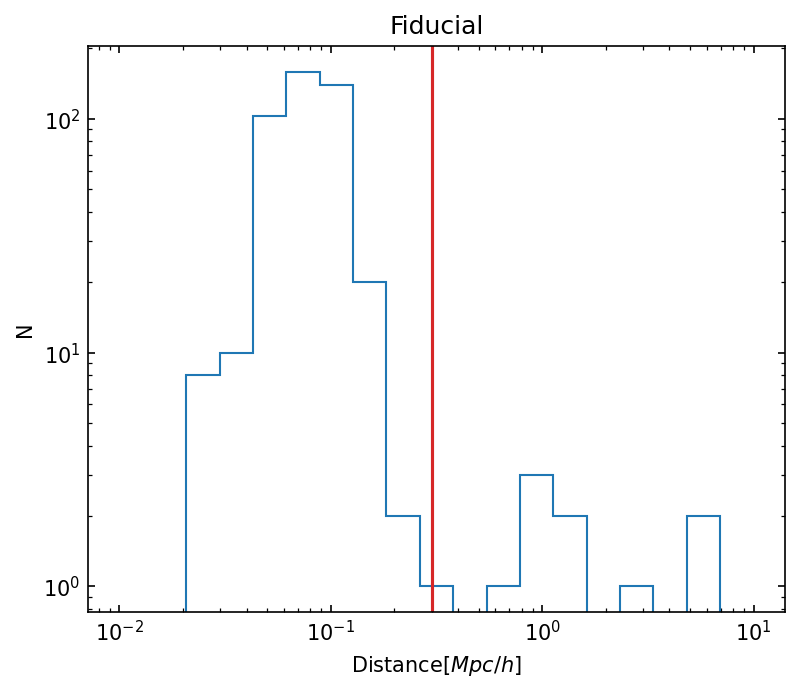

In [155]:
fig, ax = plt.subplots(dpi=150, figsize=(6,5))

ax.set_xscale('log')
ax.hist(dmatch, bins=np.logspace(-2,1,20), log=True, histtype='step')

ax.set_xlabel('Distance$[Mpc/h]$')
ax.set_ylabel('N')

plt.title('Fiducial')

ax.axvline(0.3, color='C3')

### Let's work in a specific region

We will focus on one of the zoom halos

In [136]:
Pzoom = zoom.fof['halo_pos'][psel][xmatch]
Pmtng = mtng.fof['halo_pos'][sel_z]

In [137]:
center = Pmtng[ihalo]

In [142]:
L_p = 5
z_slab = 5
xmin = np.array([center[0]-L_p/2,center[1]-L_p/2,center[2]-z_slab/2])

mtng_sel = np.where( (mtng.fof['halo_pos'][:,0]>(center[0]-L_p/2)) & (mtng.fof['halo_pos'][:,0]<(center[0]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,1]>(center[1]-L_p/2)) & (mtng.fof['halo_pos'][:,1]<(center[1]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,2]>(center[2]-z_slab/2)) & (mtng.fof['halo_pos'][:,2]<(center[2]+z_slab/2)) &\
                     (mtng.fof['halo_m200b']>0))[0]

In [149]:
zoom_grid = {}

part = ['dm', 'gas', 'stars']

for type in range(len(part)):
    zoom_sel = np.where( (getattr(zoom_snap,part[type])['pos'][:,0]>(center[0]-L_p/2)) & (getattr(zoom_snap,part[type])['pos'][:,0]<(center[0]+L_p/2)) &\
                        (getattr(zoom_snap,part[type])['pos'][:,1]>(center[1]-L_p/2)) & (getattr(zoom_snap,part[type])['pos'][:,1]<(center[1]+L_p/2)) &\
                        (getattr(zoom_snap,part[type])['pos'][:,2]>(center[2]-z_slab/2)) & (getattr(zoom_snap,part[type])['pos'][:,2]<(center[2]+z_slab/2)) )[0]

    zoom_grid[part[type]] = bacco.statistics.compute_mesh(pos=getattr(zoom_snap, part[type])['pos'][zoom_sel] - xmin[np.newaxis,:], box=L_p, ngrid=512)

2024-08-23 16:08:47,655 bacco.sims : Read data for 142907/906196 particles...
2024-08-23 16:08:47,718 bacco.sims : Read data for 142907/906196 particles...
2024-08-23 16:08:47,753 bacco.sims : Read data for 105884/906196 particles...
2024-08-23 16:08:47,786 bacco.sims : Read data for 105884/906196 particles...
2024-08-23 16:08:47,819 bacco.sims : Read data for 117704/906196 particles...


/cosmos_storage/data_sharing/MN5_resims/1pmbin_2160_legacy/fiducial/hydro_output/snapdir_094/snapshot_094.0.hdf5


2024-08-23 16:08:47,932 bacco.sims : Read data for 117704/906196 particles...
2024-08-23 16:08:47,970 bacco.sims : Read data for 106577/906196 particles...
2024-08-23 16:08:48,002 bacco.sims : Read data for 106577/906196 particles...
2024-08-23 16:08:48,038 bacco.sims : Read data for 111762/906196 particles...
2024-08-23 16:08:48,080 bacco.sims : Read data for 111762/906196 particles...
2024-08-23 16:08:48,116 bacco.sims : Read data for 111607/906196 particles...
2024-08-23 16:08:48,156 bacco.sims : Read data for 111607/906196 particles...
2024-08-23 16:08:48,189 bacco.sims : Read data for 106233/906196 particles...
2024-08-23 16:08:48,290 bacco.sims : Read data for 106233/906196 particles...
2024-08-23 16:08:48,323 bacco.sims : Read data for 103522/906196 particles...
2024-08-23 16:08:48,397 bacco.sims : Read data for 103522/906196 particles...
2024-08-23 16:08:48,403 bacco.sims :  STARS loading done in 0.788 sec


In [150]:
sel_pos = (mtng.fof['halo_pos'][mtng_sel]-xmin[np.newaxis, :])/L_p * 512

/tmp/ipykernel_131602/2797232855.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[type, i].set_xticklabels(['{:.0f}'.format(xticklabels[i]) for i in range(len(xticklabels))])
/tmp/ipykernel_131602/2797232855.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[type, i].set_yticklabels(['{:.0f}'.format(yticklabels[i]) for i in range(len(yticklabels))])


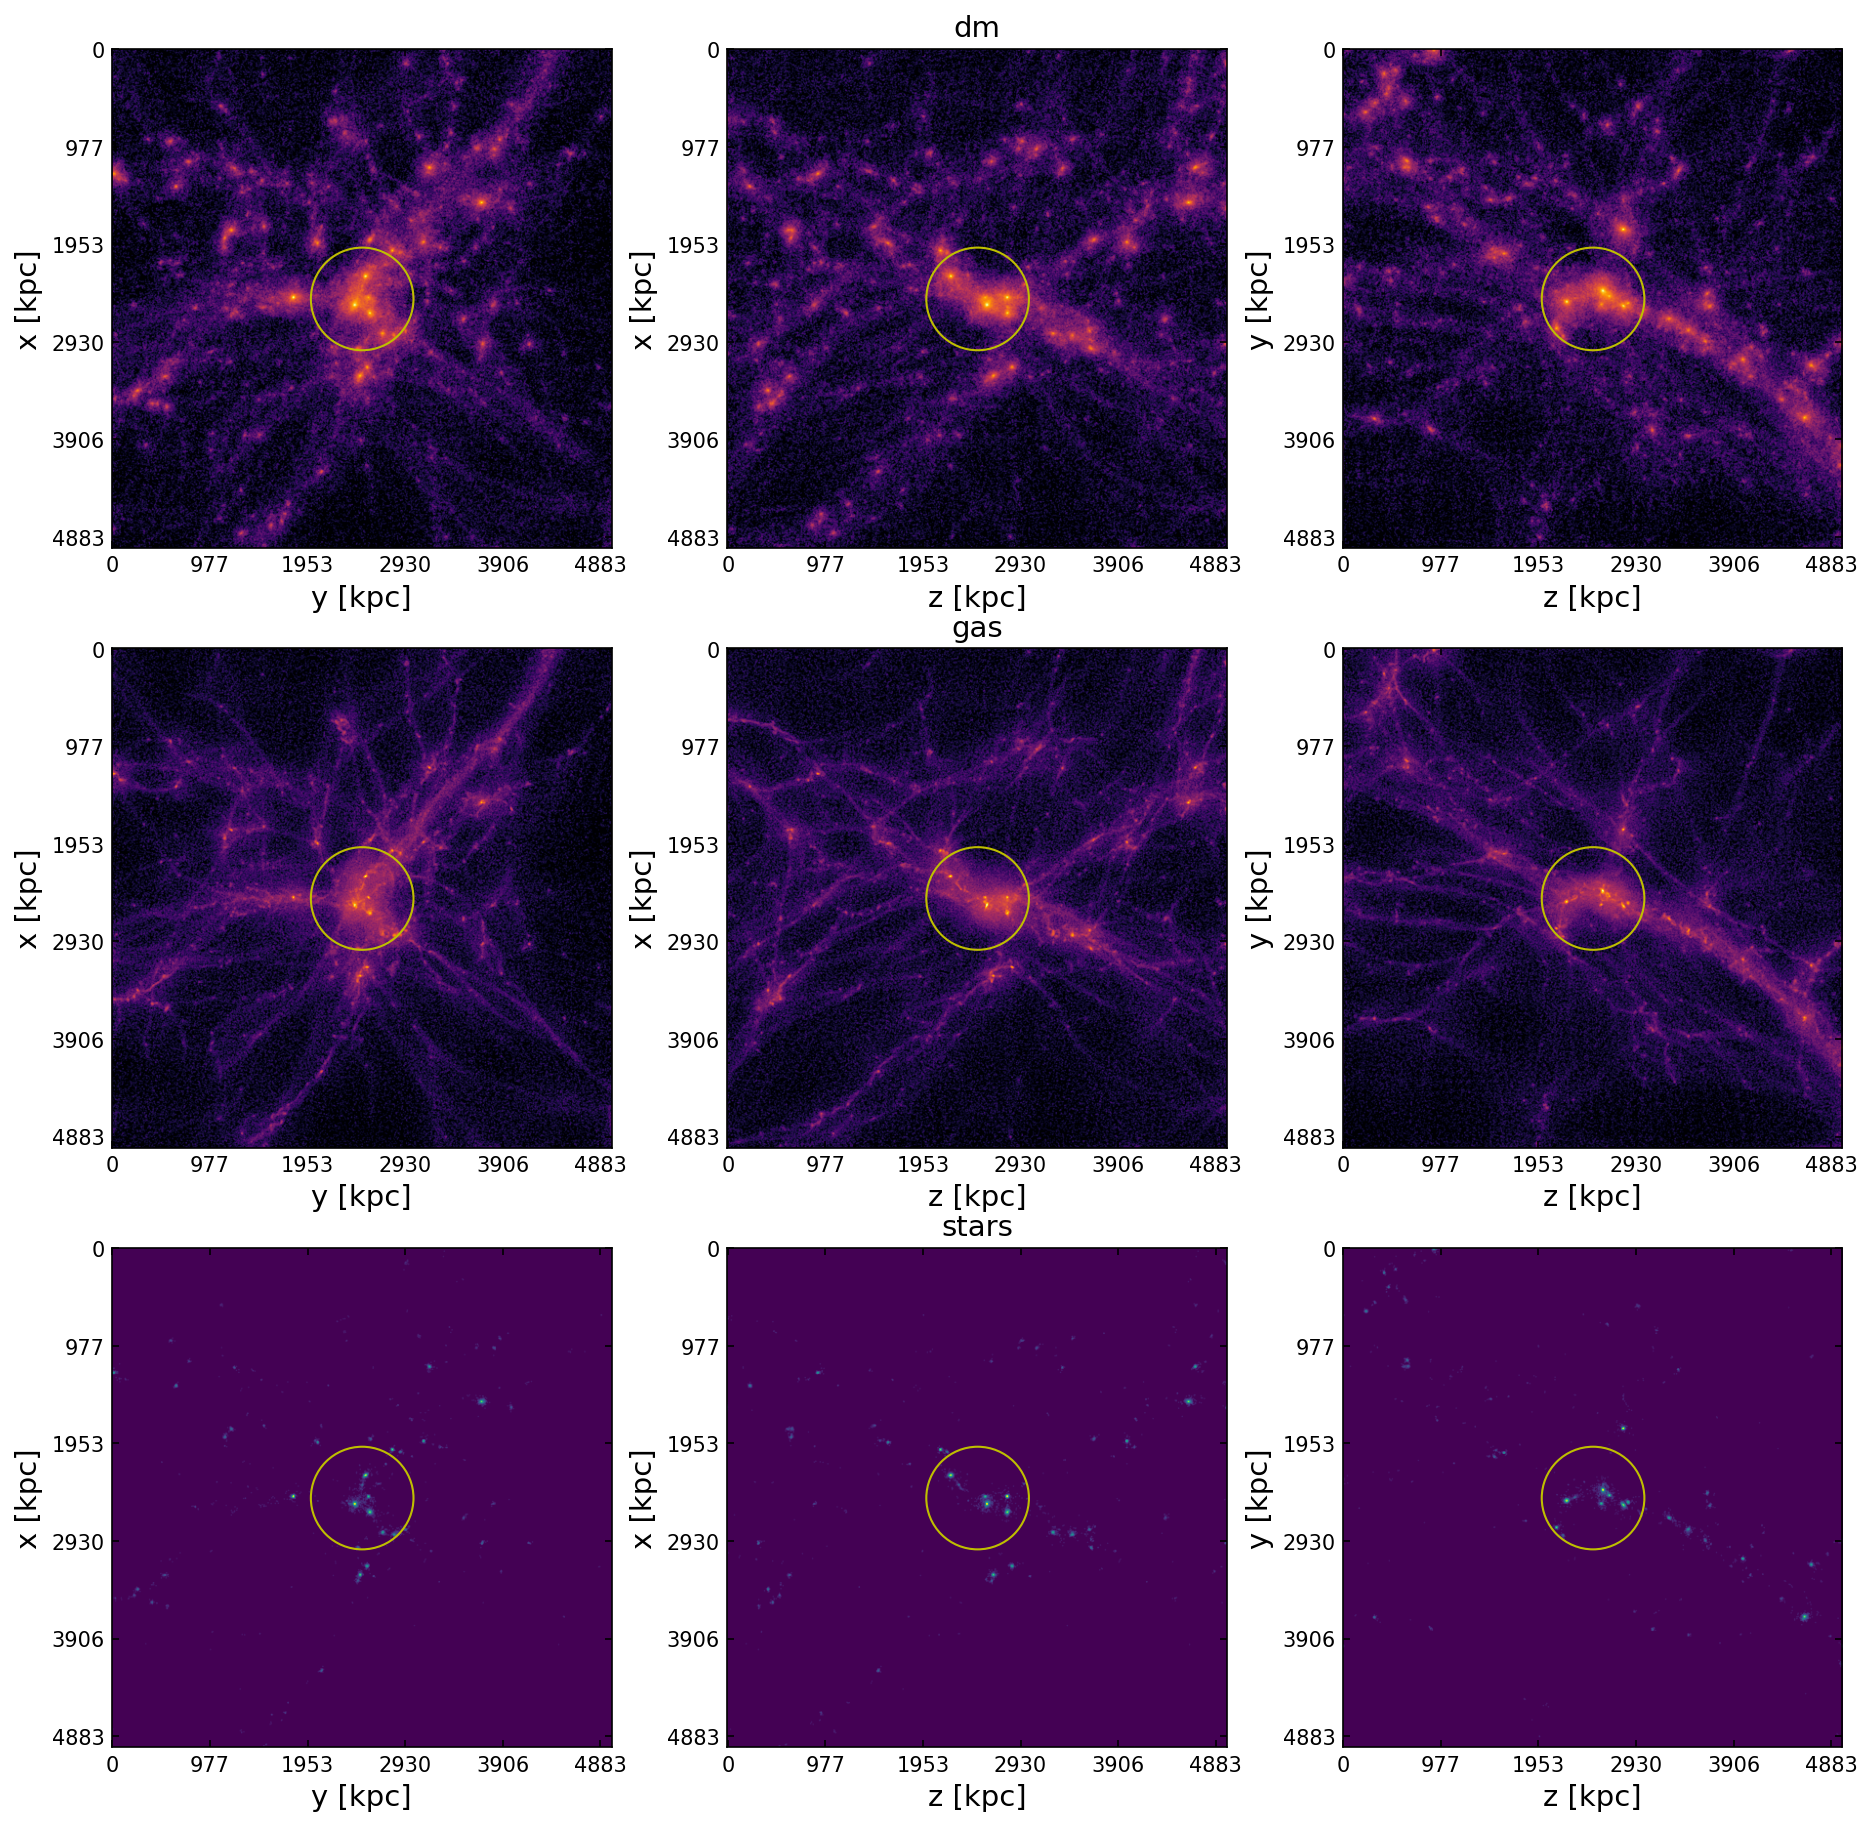

In [156]:
Pmtng_norm = (Pmtng-xmin[np.newaxis, :])/L_p * 512
Pzoom_norm = (Pzoom-xmin[np.newaxis, :])/L_p * 512

fig, ax = plt.subplots(3, 3, dpi=150, figsize=(15,15))

cmap = ['inferno', 'inferno', 'viridis']

for type in range(len(part)):
    ax[type, 0].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=2)), cmap=cmap[type])
    ax[type, 1].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=1)), cmap=cmap[type])
    ax[type, 2].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=0)), cmap=cmap[type])

    for i in range(3):
        xticklabels = 1000 * ax[type, i].get_xticks() / 512 * L_p
        yticklabels = 1000 * ax[type, i].get_yticks() / 512 * L_p
        ax[type, i].set_xticklabels(['{:.0f}'.format(xticklabels[i]) for i in range(len(xticklabels))])
        ax[type, i].set_yticklabels(['{:.0f}'.format(yticklabels[i]) for i in range(len(yticklabels))])

    ax[type, 0].set_xlabel('y [kpc]', fontsize=14)
    ax[type, 0].set_ylabel('x [kpc]', fontsize=14)

    ax[type, 1].set_xlabel('z [kpc]', fontsize=14)
    ax[type, 1].set_ylabel('x [kpc]', fontsize=14)

    ax[type, 2].set_xlabel('z [kpc]', fontsize=14)
    ax[type, 2].set_ylabel('y [kpc]', fontsize=14)

    ax[type, 1].set_title(part[type], fontsize=14)

    # for i in range(sel_pos.shape[0]):
    #     circle = plt.Circle((sel_pos[i,1],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    #     ax[0].add_artist(circle)
    #     circle = plt.Circle((sel_pos[i,2],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    #     ax[1].add_artist(circle)
    #     circle = plt.Circle((sel_pos[i,2],sel_pos[i,1]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    #     ax[2].add_artist(circle)

    # ax[0].plot( Pzoom_norm[ihalo][1], Pzoom_norm[ihalo][0], 'y*', ms=3)
    # ax[1].plot( Pzoom_norm[ihalo][2], Pzoom_norm[ihalo][0], 'y*', ms=3)
    # ax[2].plot( Pzoom_norm[ihalo][2], Pzoom_norm[ihalo][1], 'y*', ms=3)

    circle = plt.Circle((Pmtng_norm[ihalo][1], Pmtng_norm[ihalo][0]), mtng.fof['halo_r200c'][sel_z][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 0].add_artist(circle)
    circle = plt.Circle((Pmtng_norm[ihalo][2], Pmtng_norm[ihalo][0]), mtng.fof['halo_r200c'][sel_z][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 1].add_artist(circle)
    circle = plt.Circle((Pmtng_norm[ihalo][2], Pmtng_norm[ihalo][1]), mtng.fof['halo_r200c'][sel_z][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 2].add_artist(circle)

plt.savefig('../images/zoom{:d}_fid.pdf'.format(ihalo), bbox_inches='tight')

### Save the cross-match

In [172]:
np.save("/lscratch/fgmaion/MTNG-resims/cross-match/xmatch_fid.npy", [{'xmatch':psel[xmatch], 'dmatch':dmatch}])